In [14]:
import yfinance as yf
import pandas as pd
import numpy as np


# Crypto tickers
tickers = ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD", "XRP-USD"]

# Hämta data från 2018 till IDAG
raw = yf.download(tickers, start="2018-01-01", end="2026-03-11", group_by="ticker")


# Spara rå data
raw.to_csv("../data/raw_stocks.csv")
print(raw.shape)
print(raw.head())

[*********************100%***********************]  5 of 5 completed

(2991, 25)
Ticker     SOL-USD                        XRP-USD                             \
Price         Open High Low Close Volume     Open     High      Low    Close   
Date                                                                           
2018-01-01     NaN  NaN NaN   NaN    NaN  2.29602  2.39103  2.14897  2.39103   
2018-01-02     NaN  NaN NaN   NaN    NaN  2.36948  2.48919  2.24793  2.48090   
2018-01-03     NaN  NaN NaN   NaN    NaN  2.46410  3.27938  2.44315  3.10537   
2018-01-04     NaN  NaN NaN   NaN    NaN  3.11734  3.84194  3.11734  3.19663   
2018-01-05     NaN  NaN NaN   NaN    NaN  3.30081  3.56468  2.82561  3.04871   

Ticker                  ...  BNB-USD                                           \
Price           Volume  ...     Open       High      Low     Close     Volume   
Date                    ...                                                     
2018-01-01  1894230016  ...  8.62953   8.700570  7.95922   8.41461   66422800   
2018-01-02  3171010048  

In [15]:
# Titta på en crypto i taget - börja med BTC
btc = raw["BTC-USD"].copy()
btc.dropna(inplace=True)

print("Shape:", btc.shape)
print("\nNull values:\n", btc.isnull().sum())
print("\nStatistik:\n", btc.describe())

Shape: (2991, 5)

Null values:
 Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Statistik:
 Price           Open           High            Low          Close  \
count    2991.000000    2991.000000    2991.000000    2991.000000   
mean    38207.916176   38961.548473   37399.699615   38225.262774   
std     32480.948516   33005.884654   31911.082330   32482.586317   
min      3236.274658    3275.377930    3191.303467    3236.761719   
25%      9575.308105    9738.965332    9378.068848    9565.745117   
50%     28087.175781   28532.830078   27563.876953   28168.089844   
75%     59205.238281   60785.527344   58077.728516   59267.134766   
max    124752.140625  126198.070312  123196.046875  124752.531250   

Price        Volume  
count  2.991000e+03  
mean   3.056486e+10  
std    2.206771e+10  
min    2.923670e+09  
25%    1.546330e+10  
50%    2.636489e+10  
75%    4.034996e+10  
max    3.509679e+11  


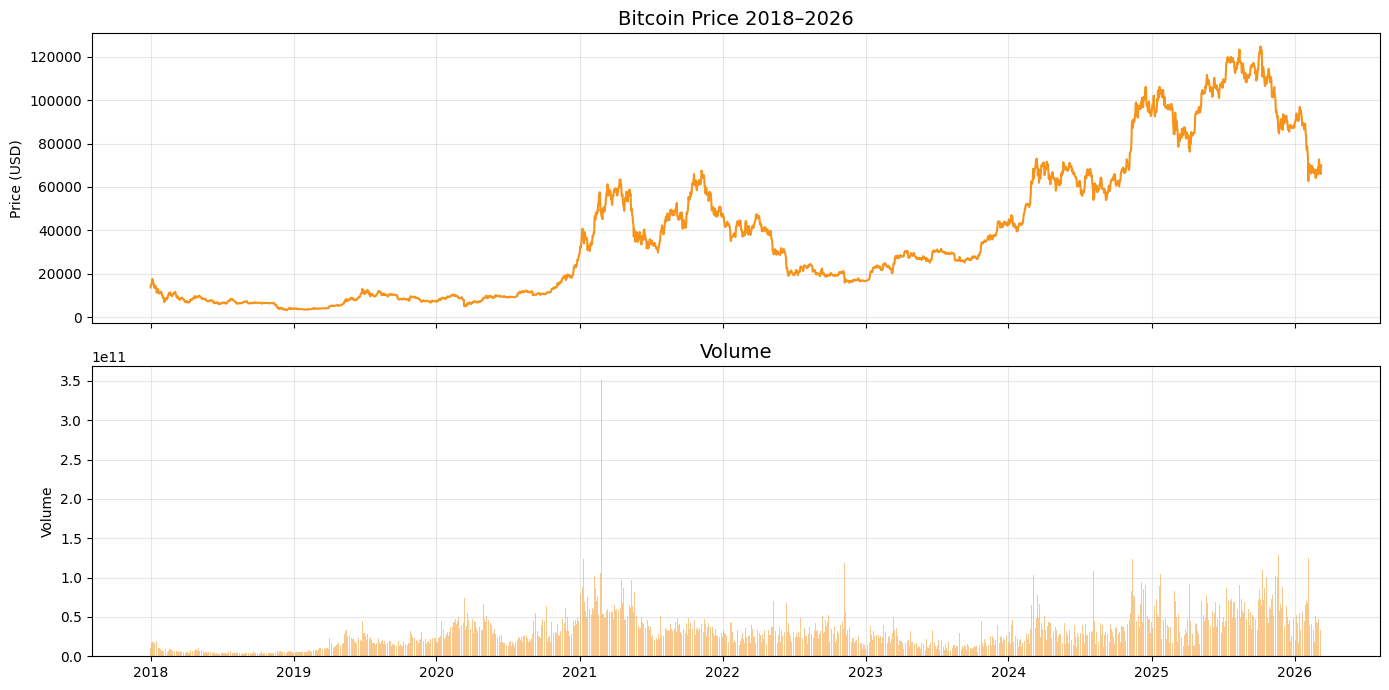

In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(btc.index, btc["Close"], color="#F7931A", linewidth=1.5)  # Bitcoin orange!
ax1.set_title("Bitcoin Price 2018–2026", fontsize=14)
ax1.set_ylabel("Price (USD)")
ax1.grid(True, alpha=0.3)

ax2.bar(btc.index, btc["Volume"], color="#F7931A", alpha=0.5)
ax2.set_title("Volume", fontsize=14)
ax2.set_ylabel("Volume")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

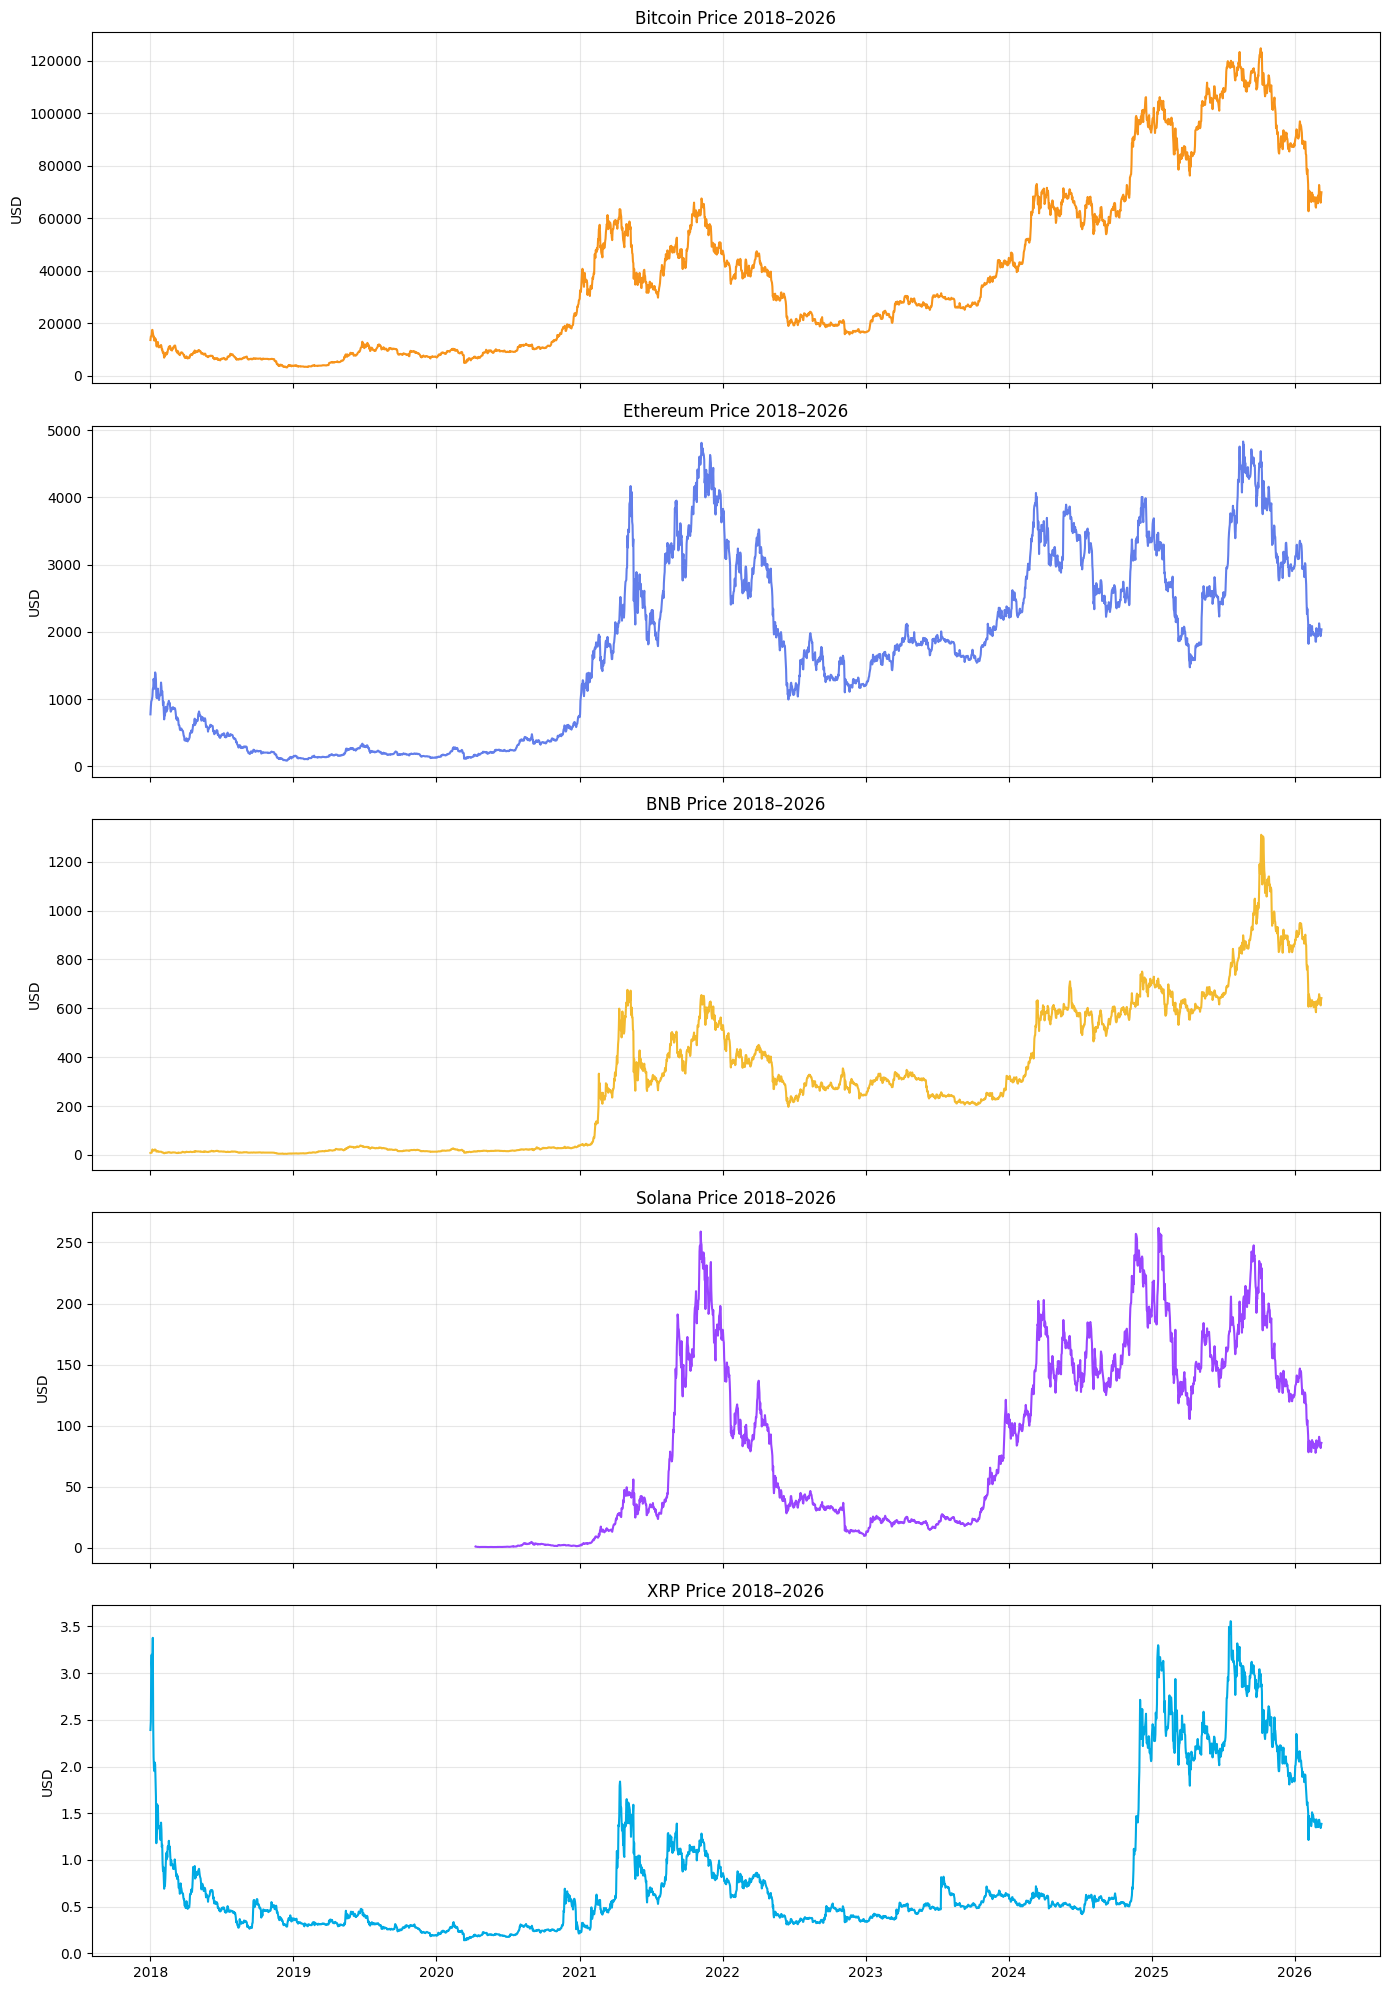

In [17]:
# Jämför alla cryptos - normaliserad (% förändring från start)
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)

cryptos = {
    "BTC-USD": ("#F7931A", "Bitcoin"),
    "ETH-USD": ("#627EEA", "Ethereum"),
    "BNB-USD": ("#F3BA2F", "BNB"),
    "SOL-USD": ("#9945FF", "Solana"),
    "XRP-USD": ("#00AAE4", "XRP")
}

for ax, (ticker, (color, name)) in zip(axes, cryptos.items()):
    coin = raw[ticker].copy().dropna()
    ax.plot(coin.index, coin["Close"], color=color, linewidth=1.5)
    ax.set_title(f"{name} Price 2018–2026", fontsize=12)
    ax.set_ylabel("USD")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
raw.to_csv("../data/raw_crypto.csv")